## Setup

In [24]:
# Import packages
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# Make plots larger
plt.rcParams["figure.figsize"] = (10, 5)

# Define log directory
LOG_DIR = Path("/rds/general/user/ll1225/home/imperial_irp/extended_evo1/training_metrics/agvla_habitatsim/stage2")
# LOG_DIR = Path("/rds/general/user/ll1225/home/imperial_irp/extended_evo1")

*Run this block if want to use log file of latest run*

In [20]:
# Get log file of latest run
csv_files = sorted(LOG_DIR.glob("training_metrics_*.csv")) # Get and sort all files ending with training_metrics_*.csv
print(f"Found {len(csv_files)} metric logs") # Print found log files
latest_file = csv_files[-1] # Get log file of latest run
print("Using:", latest_file) # Print the log file being used

Found 5 metric logs
Using: /rds/general/user/ll1225/home/imperial_irp/extended_evo1/training_metrics/agvla_habitatsim/stage1/training_metrics_20260714_104109.csv


*Run this block if want to define a specific run to use*

In [25]:
# Define specific log file to use
# FILE_NAME = "training_metrics_20260712_070310.csv" # AGVLA (base Evo1), stage 1 training (10 min test)
# FILE_NAME = "training_metrics_20260713_050542.csv" # AGVLA (base Evo1), stage 1 training
FILE_NAME = "training_metrics_20260714_102222.csv" # AGVLA (base Evo1), stage 2 training
# FILE_NAME = "training_metrics_20260720_001638.csv" # AGVLA (base Evo1), stage 2 resume 1 training
# FILE_NAME = "training_metrics_20260719_134608.csv" # AGVLA (base Evo1), only hm3d_8 stage 1 training
# FILE_NAME = "training_metrics_20260719_160654.csv" # AGVLA (base Evo1), only hm3d_2 stage 1 training
# FILE_NAME = "training_metrics_20260719_180206.csv" # AGVLA (base Evo1), only hm3d_3 stage 1 training
# FILE_NAME = "training_metrics_20260719_212435.csv" # AGVLA (base Evo1), only hm3d_9 stage 1 training
# FILE_NAME = "training_metrics_20260719_214604.csv" # AGVLA (base Evo1), only hm3d_6 stage 1 training
latest_file = LOG_DIR / FILE_NAME
print("Using", latest_file) # Print the log file being used

Using /rds/general/user/ll1225/home/imperial_irp/extended_evo1/training_metrics/agvla_habitatsim/stage2/training_metrics_20260714_102222.csv


## Plotting

#### Read CSV

In [26]:
# Read CSV file to plot
df = pd.read_csv(latest_file)
df.head() # Show CSV headings

,step,epoch,mse_loss,mae_loss,learning_rate,grad_norm
0,0,0.000000,0.101562,0.247070,1.000000e-08,0.0
1,10,0.000123,0.090332,0.234375,1.100000e-07,0.0
2,20,0.000247,0.090332,0.240234,2.100000e-07,0.0
3,30,0.000370,0.097656,0.235352,3.100000e-07,0.0
4,40,0.000494,0.099609,0.242188,4.100000e-07,0.0


#### Plot MSE loss

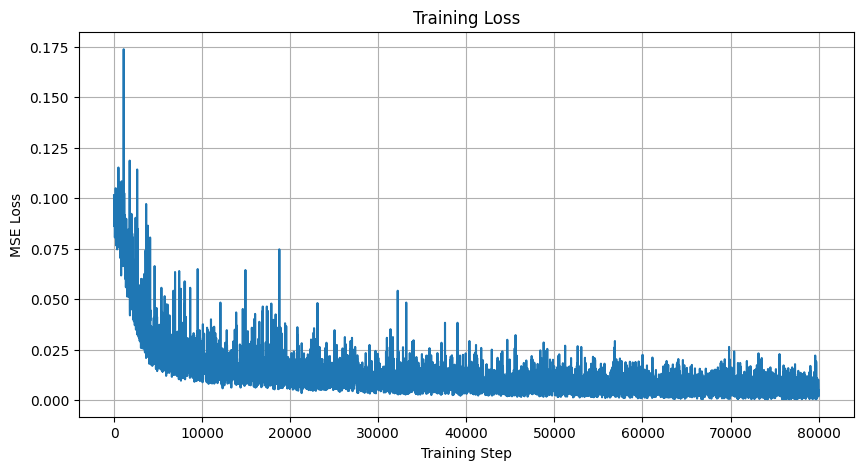

In [27]:
plt.figure()

plt.plot(df["step"], df["mse_loss"])

plt.xlabel("Training Step")
plt.ylabel("MSE Loss")
plt.title("Training Loss")

plt.grid(True)

plt.show()

#### Plot MAE loss

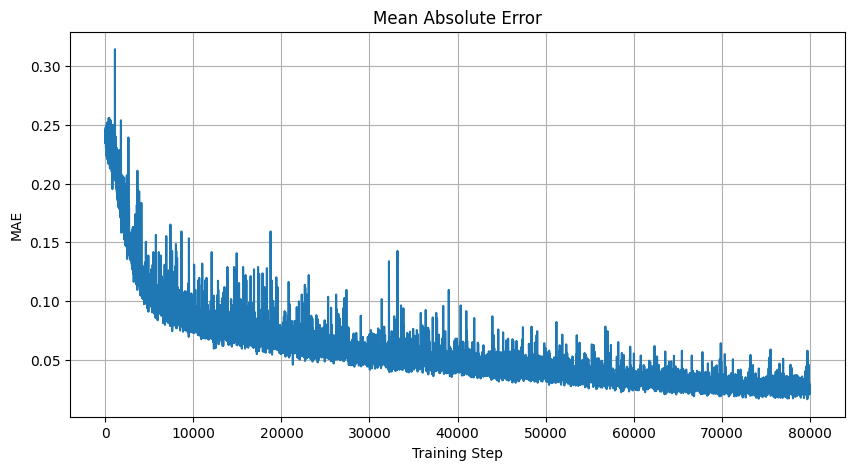

In [5]:
plt.figure()

plt.plot(df["step"], df["mae_loss"])

plt.xlabel("Training Step")
plt.ylabel("MAE")

plt.title("Mean Absolute Error")

plt.grid(True)

plt.show()

#### Plot learning rate

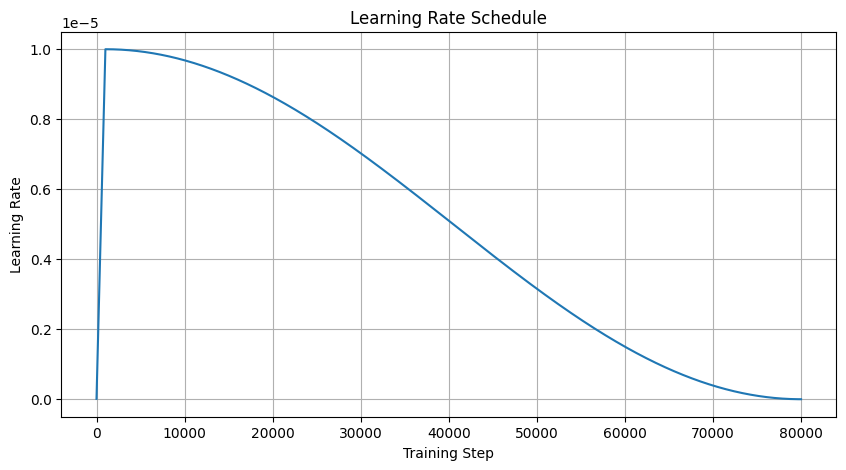

In [6]:
plt.figure()

plt.plot(df["step"], df["learning_rate"])

plt.xlabel("Training Step")
plt.ylabel("Learning Rate")

plt.title("Learning Rate Schedule")

plt.grid(True)

plt.show()

#### Plot gradient norm

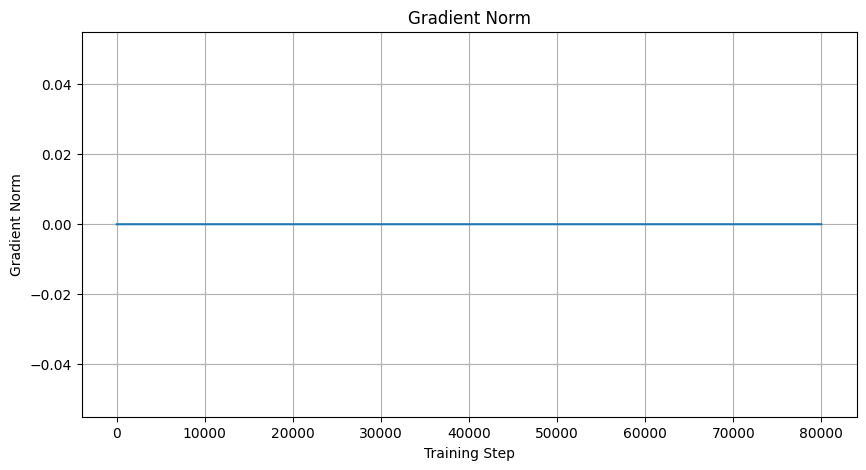

In [7]:
plt.figure()

plt.plot(df["step"], df["grad_norm"])

plt.xlabel("Training Step")
plt.ylabel("Gradient Norm")

plt.title("Gradient Norm")

plt.grid(True)

plt.show()

#### Plot everything together

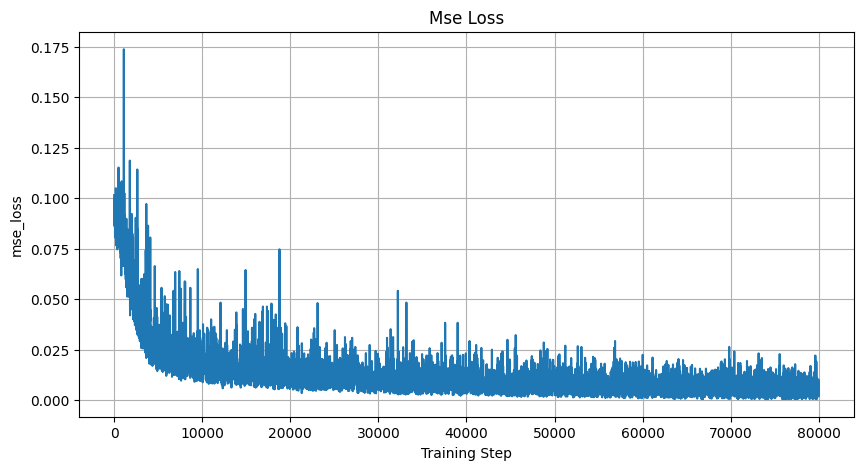

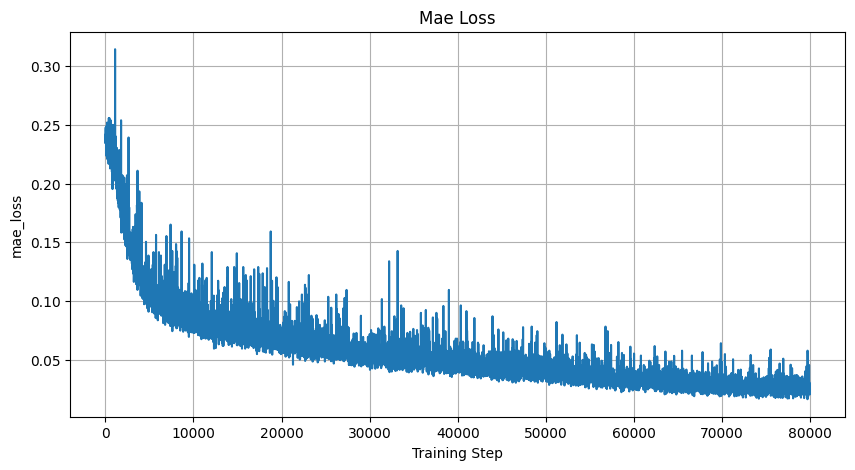

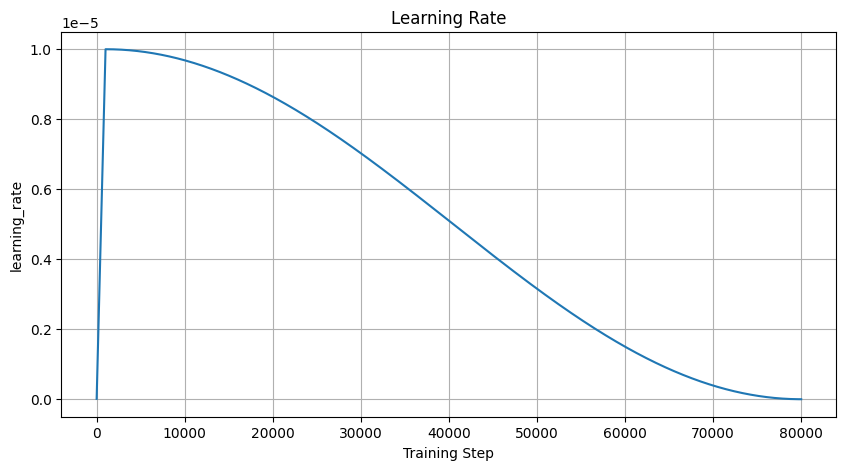

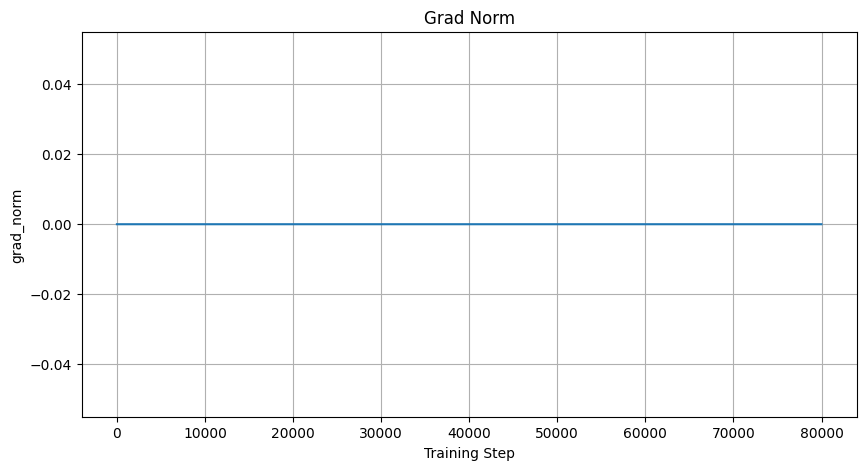

In [8]:
# Define logged metrics
metrics = [
    "mse_loss",
    "mae_loss",
    "learning_rate",
    "grad_norm",
]

# Loop through all metrics, and plot them
for metric in metrics:
    plt.figure()
    plt.plot(df["step"], df[metric])
    plt.xlabel("Training Step")
    plt.ylabel(metric)
    plt.title(metric.replace("_", " ").title())
    plt.grid(True)
    plt.show()

#### Compare multiple training runs

In [ ]:
# Get and sort all training_metrics_*.csv files
files = sorted(LOG_DIR.glob("training_metrics_*.csv"))

# Create figure
plt.figure(figsize=(10,5))

# Loop through all training metrics log files
for f in files:
    run = pd.read_csv(f)
    plt.plot(run["step"], run["mse_loss"], label=f.stem) # Plot MSE loss for each log file/training run

plt.xlabel("Step")
plt.ylabel("MSE Loss")
plt.title("Training Run Comparison")
plt.legend(fontsize=7)

plt.grid(True)

plt.show()